# Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [6]:
%pip install numpy gymnasium minatar torch tqdm

In [7]:
import numpy as np
import torch
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs

SEED = 43
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [8]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [9]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1)
    ball_pos = np.where(ball_channel == 1)

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean()
    ball_x = ball_pos[1].mean()

    if ball_x < paddle_x:
        return 1
    elif ball_x > paddle_x:
        return 2
    else:
        return 0

In [10]:
def run_episode(env, policy_fn):
    """
    Runs a single episode using the provided policy function.
    Returns the total reward and the number of steps taken.

    Parameters
    ----------
    env : gymnasium.Env
        The environment to run the episode in.
    policy_fn : function
        A function that takes an observation and the number of actions, and returns an action.
    
    Returns
    -------
    total_reward : float
        The total reward accumulated during the episode.
    steps : int
        The number of steps taken in the episode.
    """
    observation, info = env.reset()
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps


def evaluate_policy(env, policy_fn, num_episodes=100):
    """
    Evaluates a policy by running it in the environment for a specified number of episodes.

    Parameters
    ----------
    env : gymnasium.Env
        The environment to run the episodes in.
    policy_fn : function
        A function that takes an observation and the number of actions, and returns an action.
    num_episodes : int, optional
        The number of episodes to run (default is 100).

    Returns
    -------
    rewards : np.ndarray
        An array of total rewards for each episode.
    steps_list : np.ndarray
        An array of the number of steps taken in each episode.
    """
    rewards = []
    steps_list = []

    for _ in range(num_episodes):
        total_reward, steps = run_episode(env, policy_fn)
        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [11]:
env = gym.make("MinAtar/Breakout-v1")
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [12]:
num_episodes = 100

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.37 +/- 0.63
  Steps:  9.72 +/- 6.36

Heuristic Policy:
  Reward: 7.12 +/- 7.85
  Steps:  84.14 +/- 90.38


In [13]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

observations = []
rewards = []

def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn, max_steps=500):
    observation, info = env.reset()
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        observations.append(observation)
        rewards.append(reward)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 15, Steps = 166


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

2. **Action space**: What actions are available? How do they affect the game state?

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

Visualize observations, reward distributions, and episode statistics to support your analysis.

### _Answers_
1.

In [14]:
def render_observation(observation: torch.Tensor):
    for channel in range(observation.shape[2]):
        X = np.where(observation[:,:,channel]==1)[1]
        Y = np.where(observation[:,:,channel]==1)[0]
        coords = np.stack((X, Y), axis=-1)
        plt.scatter(X, Y, label=f"Channel {channel}")
        if channel == observation.shape[2] - 1:
            plt.legend(title="Channels")
    plt.xlim(0,9)
    plt.ylim(0,9)
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

Observation shape: (10, 10, 4)


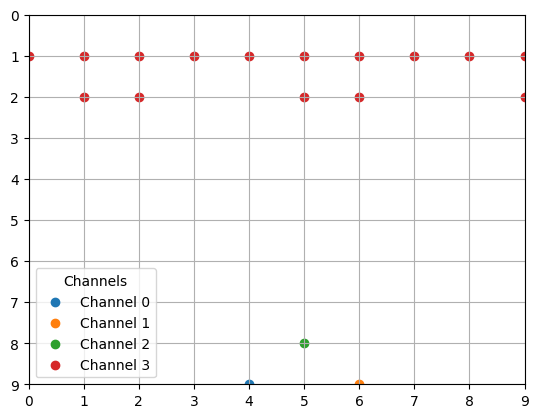

In [15]:
obs = observations[-1]
print(f"Observation shape: {obs.shape}")
render_observation(obs)


**Answer**: As demonstrated by the code above, observations have shape $(10,10,4)$:
- 1st dimension: Y coordinate, top to bottom
- 2nd dimension: X coordinate, left to right
- 3rd dimension: 0 for paddle, 1 for ball's head, 2 for ball's tail, 3 for bricks

When ignoring the constraints such as restricted positions, no intersection, ball's continuity, etc, we have  $$|\mathcal{X}|=10*10*4=400$$
2. There is 3 actions available:
- $a=0$: do nothing
- $a=1$: go right $\Rightarrow$ paddle's x coordinate incremented of 1 if possible
- $a=2$: go left $\Rightarrow$ paddle's x coordinate decremented of 1 if possible
3.

In [16]:
steps_with_reward = np.where(np.array(rewards) == 1)[0]
print(f"Steps with reward = 1: {steps_with_reward}")
avg_reward_per_step = np.sum(rewards) / (np.arange(len(rewards)) + 1)
print(f"Average reward per step: {avg_reward_per_step[-1]:.4f}")
gap_between_rewards = np.diff(steps_with_reward)
print(f"Steps between rewards: mean: {gap_between_rewards.mean():.2f}, min: {gap_between_rewards.min()}, max: {gap_between_rewards.max()}")

print(f"Heuristic reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")

Steps with reward = 1: [ 10  20  31  42  52  63  74  84  95 106 116 127 138 148 159]
Average reward per step: 0.0904
Steps between rewards: mean: 10.64, min: 10, max: 11
Heuristic reward: 7.12 +/- 7.85


**Answer**: Agent receives reward $1$ every time a brick breaks. It receives one about every $10.67$ steps, 10 to 13 depending on how far the ball went through the brick layers.

When playing the heuristic, the agent's typical return is $10.16 \pm 10.12$.

4. What causes an episode to end is either
- ball falls to the ground _i.e._ ball's head y-coordinate is 9 _i.e._ ```observation[8, :, 1].any() is True```
- all bricks are broken _i.e._ ```observation[:, :, 3].any() is False```

5. The environment is deterministic: the ball always bounces the same way. The only source of randomness is initial state of ball and paddle but it's not considered part of the environment.

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

### Answers
#### Analysis
Even though the model is known, the state space's dimension is way too large for a planning algorithm: it would be a $O(3*400^2)$ time complexity.

Then one needs to choose a learning algorithm such as fitted Q-iteration. The state space has no clear better representation than _linear_:
$$Q_\theta \in \{\theta^T\phi(x,a)\}$$

Here $\phi$ is a one-hot representation of environment and action, modulo the following compressions:
- only keep paddle's x coordinate: $y$ is always 9
- only keep bricks layers $y \in [1, 3]$: others are always empty
- transform ball tail's position into position relative to the head: 0=top, 1=topright, ..., 7=topleft, and then convert to one-hot


#### First try: 

In [17]:
from collections import deque
import random
from tqdm.notebook import trange
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Callable

dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
def evaluate(env_name: str, policy_fn, n_episodes: int = 10, seed: int = 0) -> float:
    """Evaluate a policy for n_episodes, return mean return."""
    env = gym.make(env_name)
    total_returns = []

    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i)
        ep_return = 0.0
        done = False

        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            ep_return += reward
            done = terminated or truncated

        total_returns.append(ep_return)

    env.close()
    return float(np.mean(total_returns))

In [19]:
tail_pos_encoding = {
    "top": torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0], device=device),
    "top-right": torch.tensor([0, 1, 0, 0, 0, 0, 0, 0, 0], device=device),
    "right": torch.tensor([0, 0, 1, 0, 0, 0, 0, 0, 0], device=device),
    "bottom-right": torch.tensor([0, 0, 0, 1, 0, 0, 0, 0, 0], device=device),
    "bottom": torch.tensor([0, 0, 0, 0, 1, 0, 0, 0, 0], device=device),
    "bottom-left": torch.tensor([0, 0, 0, 0, 0, 1, 0, 0, 0], device=device),
    "left": torch.tensor([0, 0, 0, 0, 0, 0, 1, 0, 0], device=device),
    "top-left": torch.tensor([0, 0, 0, 0, 0, 0, 0, 1, 0], device=device),
    "coincident": torch.tensor([0, 0, 0, 0, 0, 0, 0, 0, 1], device=device)
}

def phi_minatar(observation: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
    """
        State-space representation function returning a custom one-hot encoding of (x,a).
        Inputs can be either batched or not. If only one of them is batched, the other will be automatically expanded to match the batch size.

        Parameters
        ----------
        observation : torch.Tensor
            The observation from the environment, expected to be a 3D tensor with shape (height, width, channels) or (batch_size, height, width, channels).
        actions : torch.Tensor
            The list of actions on which we want to evaluate, expected to be a 1D tensor with shape (num_actions,) or (batch_size, num_actions). 

        Returns
        ----------
        res : torch.Tensor
            A tensor where each row corresponds to the feature vector for a given action, with shape (num_actions, feature_dim) or (batch_size, num_actions, feature_dim).

    """
    actions = actions.to(device)
    observation = observation.to(device)
    actions_batched = len(actions.shape) == 2
    observation_batched = len(observation.shape) == 4
    batched = actions_batched or observation_batched
    if batched:
        if observation_batched and not actions_batched:
            actions = actions.unsqueeze(0).expand(observation.shape[0], -1)
        elif actions_batched and not observation_batched:
            observation = observation.unsqueeze(0).expand(actions.shape[0], -1, -1, -1)
        else: # Case when both are batched
            assert actions.shape[0] == observation.shape[0], f"Batch sizes should be the same, got {actions.shape[0]} for actions and {observation.shape[0]} for observation."
    else:
        actions = actions.unsqueeze(0)
        observation = observation.unsqueeze(0)
    batch_size = observation.shape[0]

    observation = observation.float()

    head_pos = torch.nonzero(observation[..., 1])[..., 1:]
    tail_pos = torch.nonzero(observation[..., 2])[..., 1:]

    deltay = (tail_pos[..., 0] - head_pos[..., 0]).unsqueeze(-1)
    deltax = (tail_pos[..., 1] - head_pos[..., 1]).unsqueeze(-1)

    # The following computes tail's relative position from 0 (top) to 7 (topleft), clockwise
    zeros = torch.zeros_like(deltay, device=device)
    tail_relative_pos_onehot = torch.zeros((batch_size, 9), device=device) \
        + torch.where((deltay == -1) & (deltax == 0), tail_pos_encoding["top"], zeros) \
        + torch.where((deltay == -1) & (deltax == 1), tail_pos_encoding["top-right"], zeros) \
        + torch.where((deltay == 0) & (deltax == 1), tail_pos_encoding["right"], zeros) \
        + torch.where((deltay == 1) & (deltax == 1), tail_pos_encoding["bottom-right"], zeros) \
        + torch.where((deltay == 1) & (deltax == 0), tail_pos_encoding["bottom"], zeros) \
        + torch.where((deltay == 1) & (deltax == -1), tail_pos_encoding["bottom-left"], zeros) \
        + torch.where((deltay == 0) & (deltax == -1), tail_pos_encoding["left"], zeros) \
        + torch.where((deltay == -1) & (deltax == -1), tail_pos_encoding["top-left"], zeros) \
        + torch.where((deltay == 0) & (deltax == 0), tail_pos_encoding["coincident"], zeros)

    head_pos_x_onehot = torch.arange(10, device=device).expand(batch_size, -1) == head_pos[..., 1].unsqueeze(-1)
    head_pos_y_onehot = torch.arange(10, device=device).expand(batch_size, -1) == head_pos[..., 0].unsqueeze(-1)

    # FIX: use x-index from nonzero(...), not batch index
    paddle_x = torch.nonzero(observation[:, 9, :, 0])[:, 1]
    paddle_x_onehot = torch.arange(10, device=device).expand(batch_size, -1) == paddle_x.unsqueeze(-1)

    bricks_pos_onehot = observation[:,1:4,:,3].flatten(start_dim=1)

    action_onehot = (torch.arange(0, 3, device=device).unsqueeze(0) == actions.unsqueeze(-1)).to(device)
    obs_onehot = torch.cat(
        [
            bricks_pos_onehot,
            paddle_x_onehot.float(),
            tail_relative_pos_onehot.float(),
            head_pos_x_onehot.float(),
            head_pos_y_onehot.float(),
        ],
        dim=1,
    )

    res = torch.cat(
        [
            obs_onehot.unsqueeze(1).expand(-1, action_onehot.shape[1], -1),
            action_onehot.float(),
        ],
        dim=-1
    )

    if not batched:
        res = res.squeeze(0)

    return res
    


Example

/tmp/ipython-input-1913925805.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  obs = torch.tensor(observations[:3])


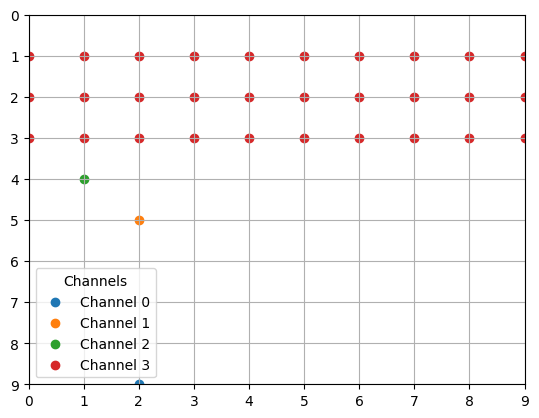

Bricks presence: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
Paddle x index: tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
Tail relative position: tensor([0., 0., 0., 0., 0., 0., 0., 1., 0.], device='cuda:0')
Head x position: tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
Head y position: tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.], device='cuda:0')
Action one-hot: tensor([1., 0., 0.], device='cuda:0')


In [15]:
obs = torch.tensor(observations[:3])
example_obs = obs[1]
render_observation(example_obs)
actions = torch.tensor([0, 1, 2])
phi_example = phi_minatar(obs, actions)[1,0]
print("Bricks presence:", phi_example[:30])
print("Paddle x index:", phi_example[30:40])
print("Tail relative position:", phi_example[40:49])
print("Head x position:", phi_example[49:59])
print("Head y position:", phi_example[59:69])
print("Action one-hot:", phi_example[69:72])

In [20]:
class ReplayBuffer:
    """Fixed-size FIFO buffer storing (s, a, r, s', done) transitions."""

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def __len__(self) -> int:
        return len(self.buffer)

    def sample(self, batch_size: int):
        """Sample a random mini-batch of transitions."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to tensors
        actions_arr = np.array(actions)
        if actions_arr.dtype in (np.float32, np.float64):
            actions_t = torch.FloatTensor(actions_arr).to(device)
        else:
            actions_t = torch.LongTensor(actions_arr).to(device)

        return (
            torch.FloatTensor(np.array(states)).to(device),
            actions_t,
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device),
        )

In [21]:
class Agent(ABC):
    """Base class for all RL agents."""

    @abstractmethod
    def act(self, state: np.ndarray, explore: bool = True):
        """Select an action given the current state."""
        ...

    @abstractmethod
    def update(self, **kwargs):
        """Update internal estimates from experience."""
        ...

In [18]:
class FQIAgent(Agent):
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        feature_dim: int,
        phi: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        lr: float = 1e-3,
        gamma: float = 0.99,
        buffer_size: int = 10_000,
        batch_size: int = 64,
        target_update_freq: int = 200, # Frequency (in steps) to update the target network
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay_steps: int = 5000,
    ):
        """
        Initializes the FQI agent with the given hyperparameters.

        Parameters
        ----------
        state_dim : int
            Dimension of the state space (e.g., 4 for CartPole-v1).
        action_dim : int
            Dimension of the action space (e.g., 2 for CartPole-v1).
        feature_dim : int
            Dimension of the feature space returned by the representation function phi.
        lr : float, optional
            Learning rate for the Adam optimizer.
        gamma : float, optional
            Discount factor for future rewards.
        phi : Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
            State-space representation function that takes an observation and a set of actions, and returns a feature matrix.
        buffer_size : int, optional
            Maximum capacity of the replay buffer.
        batch_size : int, optional
            Size of the mini-batch sampled from the replay buffer.
        epsilon_start : float, optional
            Initial exploration rate.
        epsilon_end : float, optional
            Minimum exploration rate.
        epsilon_decay_steps : int, optional
            Number of steps over which epsilon decays.
        """
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Linear model and representation function
        self.phi = phi
        self.q_linear = nn.Linear(feature_dim, 1, bias=True, device=device)
        self.target_linear = nn.Linear(feature_dim, 1, bias=True, device=device)
        self.target_linear.load_state_dict(self.q_linear.state_dict())

        self.optimizer = torch.optim.Adam(self.q_linear.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)

        # Epsilon schedule
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.step_count = 0

    # GPI Improvement step: epsilon greedy action selection
    @torch.no_grad()
    def act(self, state: np.ndarray, explore: bool = True) -> int:
        """Epsilon-greedy action selection."""
        # With probability epsilon, take random action
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        # Otherwise, take greedy action
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        actions_return = self.q_linear(self.phi(state_t, torch.arange(self.action_dim, device=device)))
        return int(actions_return.argmax(dim=1).item())

    # GPI Evaluation stept: Q-function update via gradient descent
    def update(self, **kwargs) -> float | None:
        """One gradient step on the Double-DQN loss."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s, a) for the actions actually taken
        q_values = self.q_linear(self.phi(states, actions.unsqueeze(-1))).squeeze()

        with torch.no_grad():
            # best_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            # next_q = self.target_net(next_states).gather(1, best_actions).squeeze(1)
            # targets = rewards + self.gamma * next_q * (1 - dones)

            # all_actions = torch.arange(self.action_dim, device=device).unsqueeze(0).expand(self.batch_size, -1)
            # q_next_all = self.linear(self.phi(next_states, all_actions)).squeeze(-1)
            # next_q = q_next_all.max(dim=1).values
            # targets = rewards + self.gamma * next_q * (1 - dones)   

            all_actions = torch.arange(self.action_dim, device=device).unsqueeze(0).expand(self.batch_size, -1)
            best_actions = self.q_linear(self.phi(next_states, all_actions)).argmax(dim=1, keepdim=True)
            next_q = self.target_linear(self.phi(next_states, all_actions)).gather(1, best_actions).squeeze()
            targets = rewards + self.gamma * next_q * (1 - dones)   

        loss = F.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon and update target network
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_linear.load_state_dict(self.q_linear.state_dict())

        return loss.item()

In [19]:
def train_FQI(
    agent: FQIAgent,
    env_name: str,
    n_episodes: int = 300,
    seed: int = 42,
    eval_every: int = 20,
    desc: str = "Training",
    store_action=None,
) -> list[float]:
    """Training loop for Fitted Q-Iteration"""
    env = gym.make(env_name)
    episode_returns: list[float] = []

    pbar = trange(n_episodes, desc=desc)
    for ep in pbar:
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0.0
        done = False

        # === EPISODE LOOP ===
        # Each iteration: act -> step -> store -> sample -> update
        while not done:
            # 1. ACT: Select action using current policy (with exploration)
            action = agent.act(state)

            # 2. STEP: Execute action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 3. STORE: Save transition to replay buffer
            if store_action is not None:
                store_action(agent, state, action, reward, next_state, done)
            else:
                agent.buffer.push(state, action, reward, next_state, float(done))

            # 4. UPDATE: Sample a random batch and perform gradient step
            agent.update()
            state = next_state
            ep_return += reward

        episode_returns.append(ep_return)

        if ep % eval_every == 0:
            eval_score = evaluate(env_name, lambda s: agent.act(s, explore=False))
            postfix = {"ret": f"{ep_return:.0f}", "eval": f"{eval_score:.0f}"}
            if hasattr(agent, "epsilon"):
                postfix["eps"] = f"{agent.epsilon:.2f}"
            pbar.set_postfix(**postfix)

    env.close()
    return episode_returns

In [22]:
def set_seed(seed: int = 42) -> None:
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [21]:
# SEEDS = [1, 2, 3]
SEEDS = [2]
dqn_runs = []
s = 1
for s in SEEDS:
    set_seed(s)
    env = gym.make("MinAtar/Breakout-v1")
    agent = FQIAgent(
        state_dim=env.observation_space.shape[0],
        action_dim=env.action_space.n,
        feature_dim=72,
        phi=phi_minatar
        )
    env.close()
    dqn_runs.append(
        train_FQI(agent, "MinAtar/Breakout-v1", n_episodes=500, seed=s, desc=f"DQN seed={s}")
    )

fqi_agent = agent  # keep last for video

DQN seed=2:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [23]:
def record_video(env_name: str, policy_fn, max_steps: int = 500, seed: int = 0):
    """Record a single episode and return an HTML5 video."""
    from matplotlib import animation
    from IPython.display import HTML

    env = gym.make(env_name, render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    done = False
    step = 0

    while not done and step < max_steps:
        action = policy_fn(state)
        state, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
        step += 1
    env.close()

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.axis("off")
    img = ax.imshow(frames[0])
    def update(f):
        img.set_data(f)
        return [img]
    anim = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
evaluate("MinAtar/Breakout-v1", lambda s: agent.act(s, explore=False))

0.4

In [ ]:
record_video("MinAtar/Breakout-v1", lambda s: fqi_agent.act(s, explore=False), seed=SEEDS[0])

/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:334: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/utils/passive_env_checker.py:275: UserWarning: WARN: RGB-array rendering should return a numpy array with dtype uint8, got float64
  logger.warn(


---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

3. **Architecture**: What neural network architecture did you use? Justify your design choices.

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

In [28]:
def mlp(
    input_dim: int,
    output_dim: int,
    hidden_dims: list[int] = [128, 128, 128, 128],
    output_activation: type[nn.Module] | None = None,
) -> nn.Sequential:
    """Build a simple MLP with ReLU hidden activations."""
    layers: list[nn.Module] = []
    prev_dim = input_dim
    for h in hidden_dims:
        layers += [nn.Linear(prev_dim, h), nn.ReLU()]
        prev_dim = h
    layers.append(nn.Linear(prev_dim, output_dim))
    if output_activation is not None:
        layers.append(output_activation())
    return nn.Sequential(*layers)

In [42]:
from typing import Union
from torch.optim.lr_scheduler import MultiStepLR

class DQNAgent(Agent):
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        feature_dim: int,
        phi: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
        lr: float = 1e-3,
        lr_milestones: list[int] = [],
        gamma: float = 0.99,
        buffer_size: int = 10_000,
        batch_size: int = 64,
        target_update_freq: int = 200, # Frequency (in steps) to update the target network
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay_steps: int = 5000,
    ):
        """
        Initializes the FQI agent with the given hyperparameters.

        Parameters
        ----------
        state_dim : int
            Dimension of the state space (e.g., 4 for CartPole-v1).
        action_dim : int
            Dimension of the action space (e.g., 2 for CartPole-v1).
        feature_dim : int
            Dimension of the feature space returned by the representation function phi.
        lr : float, optional
            Learning rate for the Adam optimizer.
        lr_milestones : list[int], optional
            Milestones for the learning rate scheduler. If provided, the learning rate will be decayed by a factor of 0.1 at each milestone.
        gamma : float, optional
            Discount factor for future rewards.
        phi : Callable[[torch.Tensor, torch.Tensor], torch.Tensor]
            State-space representation function that takes an observation and a set of actions, and returns a feature matrix.
        buffer_size : int, optional
            Maximum capacity of the replay buffer.
        batch_size : int, optional
            Size of the mini-batch sampled from the replay buffer.
        epsilon_start : float, optional
            Initial exploration rate.
        epsilon_end : float, optional
            Minimum exploration rate.
        epsilon_decay_steps : int, optional
            Number of steps over which epsilon decays.
        """
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Linear model and representation function
        self.phi = phi
        self.q_net = mlp(feature_dim, 1).to(device=device)
        self.target_net = mlp(feature_dim, 1).to(device=device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.scheduler = MultiStepLR(self.optimizer, milestones=lr_milestones, gamma=0.1)
        self.buffer = ReplayBuffer(buffer_size)

        # Epsilon schedule
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps
        self.step_count = 0

    # GPI Improvement step: epsilon greedy action selection
    @torch.no_grad()
    def act(self, state: np.ndarray, explore: bool = True) -> int:
        """Epsilon-greedy action selection."""
        # With probability epsilon, take random action
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        # Otherwise, take greedy action
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        actions_return = self.q_net(self.phi(state_t, torch.arange(self.action_dim, device=device)))
        return int(actions_return.argmax(dim=1).item())

    # GPI Evaluation stept: Q-function update via gradient descent
    def update(self, **kwargs) -> float | None:
        """One gradient step on the Double-DQN loss."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s, a) for the actions actually taken
        q_values = self.q_net(self.phi(states, actions.unsqueeze(-1))).squeeze()

        with torch.no_grad():
            all_actions = torch.arange(self.action_dim, device=device).unsqueeze(0).expand(self.batch_size, -1)
            phi = self.phi(next_states, all_actions)
            best_actions = self.q_net(phi).argmax(dim=1, keepdim=True)
            next_q = self.target_net(phi).gather(1, best_actions).squeeze()
            targets = rewards + self.gamma * next_q * (1 - dones)   

        loss = F.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Decay epsilon and update target network
        self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)
        self.step_count += 1
        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

In [ ]:
def train_DQN(
    agent: DQNAgent,
    env_name: str,
    n_episodes: int = 300,
    seed: int = 42,
    eval_every: int = 20,
    desc: str = "Training",
    store_action=None,
) -> list[float]:
    """Training loop for Fitted Q-Iteration"""
    env = gym.make(env_name)
    episode_returns: list[float] = []

    pbar = trange(n_episodes, desc=desc)
    for ep in pbar:
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0.0
        done = False

        # === EPISODE LOOP ===
        # Each iteration: act -> step -> store -> sample -> update
        while not done:
            # 1. ACT: Select action using current policy (with exploration)
            action = agent.act(state)

            # 2. STEP: Execute action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 3. STORE: Save transition to replay buffer
            if store_action is not None:
                store_action(agent, state, action, reward, next_state, done)
            else:
                agent.buffer.push(state, action, reward, next_state, float(done))

            # 4. UPDATE: Sample a random batch and perform gradient step
            agent.update()
            state = next_state
            ep_return += reward
            
        agent.scheduler.step()
        episode_returns.append(ep_return)

        if ep % eval_every == 0:
            eval_score = evaluate(env_name, lambda s: agent.act(s, explore=False))
            postfix = {"ret": f"{ep_return:.0f}", "eval": f"{eval_score:.0f}", "lr": f"{agent.scheduler.get_last_lr()[0]:.1e}"}
            if hasattr(agent, "epsilon"):
                postfix["eps"] = f"{agent.epsilon:.2f}"
            pbar.set_postfix(**postfix)

    env.close()
    return episode_returns

In [56]:
seed = 1
set_seed(seed)
env = gym.make("MinAtar/Breakout-v1")
agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    feature_dim=72,
    phi=phi_minatar,
    lr_milestones=[500,1000],
    epsilon_decay_steps=15000,
    )
env.close()
res = train_DQN(agent, "MinAtar/Breakout-v1", n_episodes=1500,  seed=seed, desc=f"DQN seed={seed}")

dqn_agent = agent

DQN seed=1:   0%|          | 0/1500 [00:00<?, ?it/s]

/tmp/ipython-input-3047166106.py:41: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  agent.scheduler.step()


In [57]:
evaluate("MinAtar/Breakout-v1", lambda s: dqn_agent.act(s, explore=False), seed=seed)

6.8

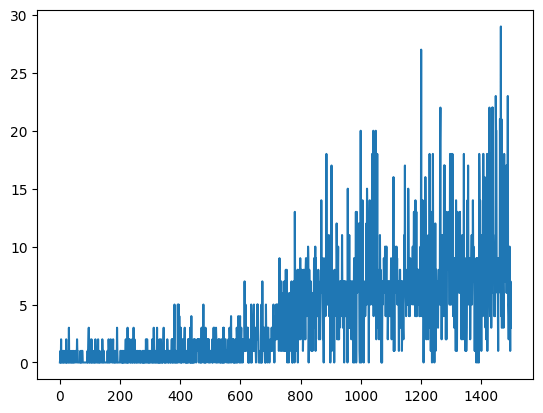

In [58]:
plt.plot(res)

Now that concept is prooved, let's improve it: first, we can try different values for $\gamma$. With an average 

In [ ]:
GAMMA = [0.7,0.8,0.9]
seed = SEEDS[0]
agents = []
for g in GAMMA:
    set_seed(seed)
    env = gym.make("MinAtar/Breakout-v1")
    agent = DQNAgent(
        state_dim=env.observation_space.shape[0],
        action_dim=env.action_space.n,
        feature_dim=72,
        phi=phi_minatar,
        gamma=g
        )
    env.close()
    train_DQN(agent, "MinAtar/Breakout-v1", n_episodes=500, seed=seed, desc=f"DQN gamma={g}")
    agents.append(agent)
for g, a in zip(GAMMA, agents):
    eval_score = evaluate("MinAtar/Breakout-v1", lambda s: a.act(s, explore=False))
    print(f"Gamma: {g}, Eval Score: {eval_score:.2f}")

DQN gamma=0.7:   0%|          | 0/500 [00:00<?, ?it/s]

DQN gamma=0.8:   0%|          | 0/500 [00:00<?, ?it/s]

DQN gamma=0.9:   0%|          | 0/500 [00:00<?, ?it/s]

Gamma: 0.7, Eval Score: 3.10
Gamma: 0.8, Eval Score: 6.40
Gamma: 0.9, Eval Score: 5.80


Best score is for $\gamma = 0.8$, let's keep this value.

In [ ]:
s = 1
set_seed(s)
env = gym.make("MinAtar/Breakout-v1")
agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    feature_dim=72,
    phi=phi_minatar,
    gamma=0.99,
    epsilon_decay_steps=15000,
    )
env.close()
res = train_DQN(agent, "MinAtar/Breakout-v1", n_episodes=1500, seed=s, desc=f"DQN seed={s}")

DQN seed=1:   0%|          | 0/1500 [00:00<?, ?it/s]

In [ ]:
evaluate("MinAtar/Breakout-v1", lambda s: agent.act(s, explore=False), n_episodes=30, seed=seed)

6.966666666666667

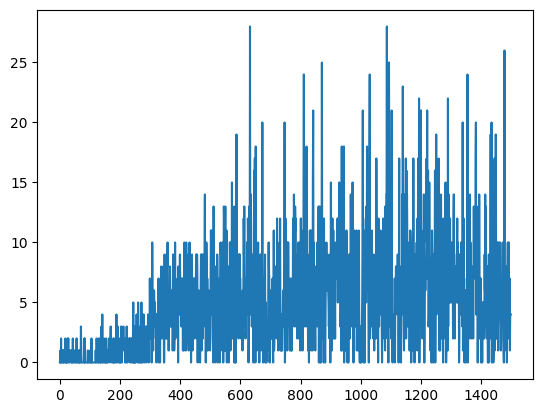

In [ ]:
plt.plot(res)

---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.


---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.